### Xây dựng Multi-Agent để phát triển một sub-video/chủ đề thành một bài giảng hoàn chỉnh

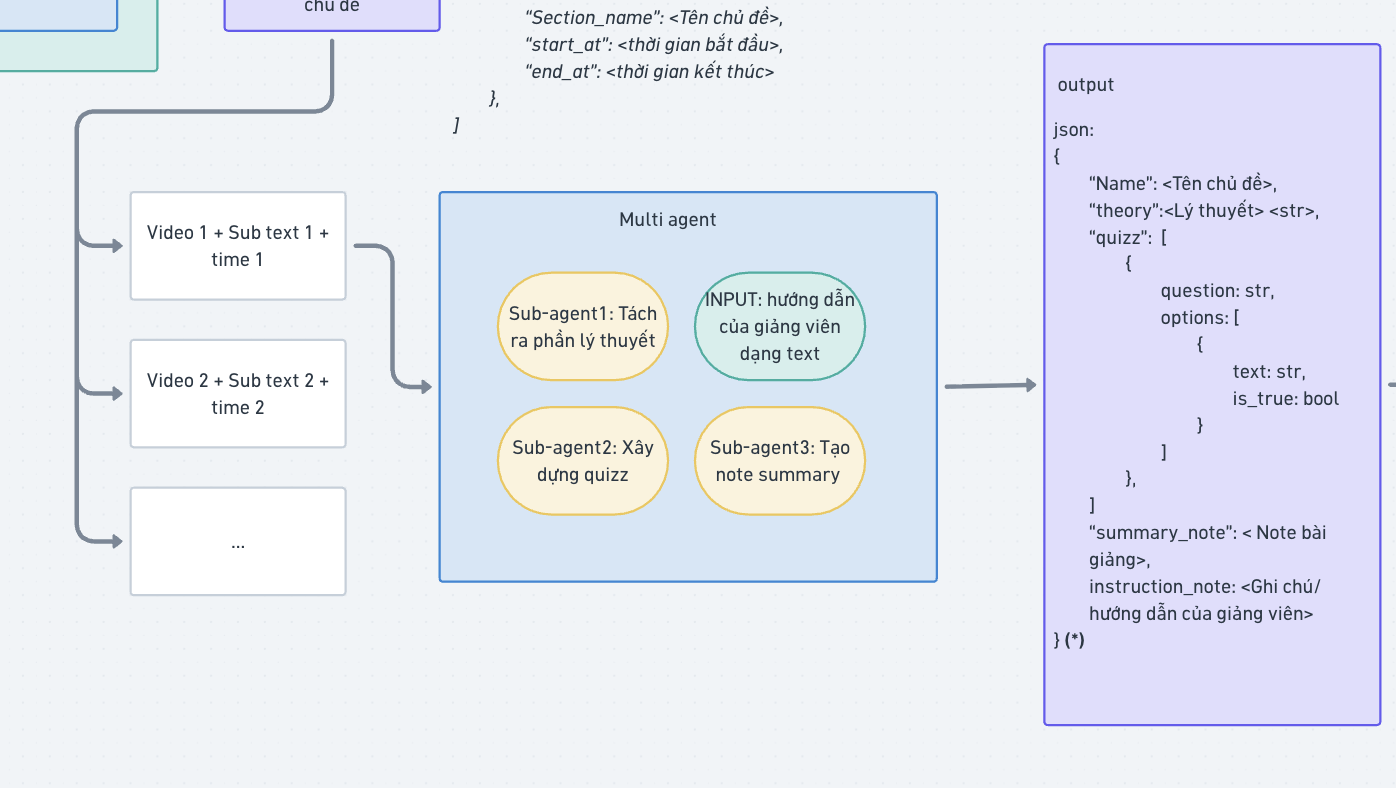

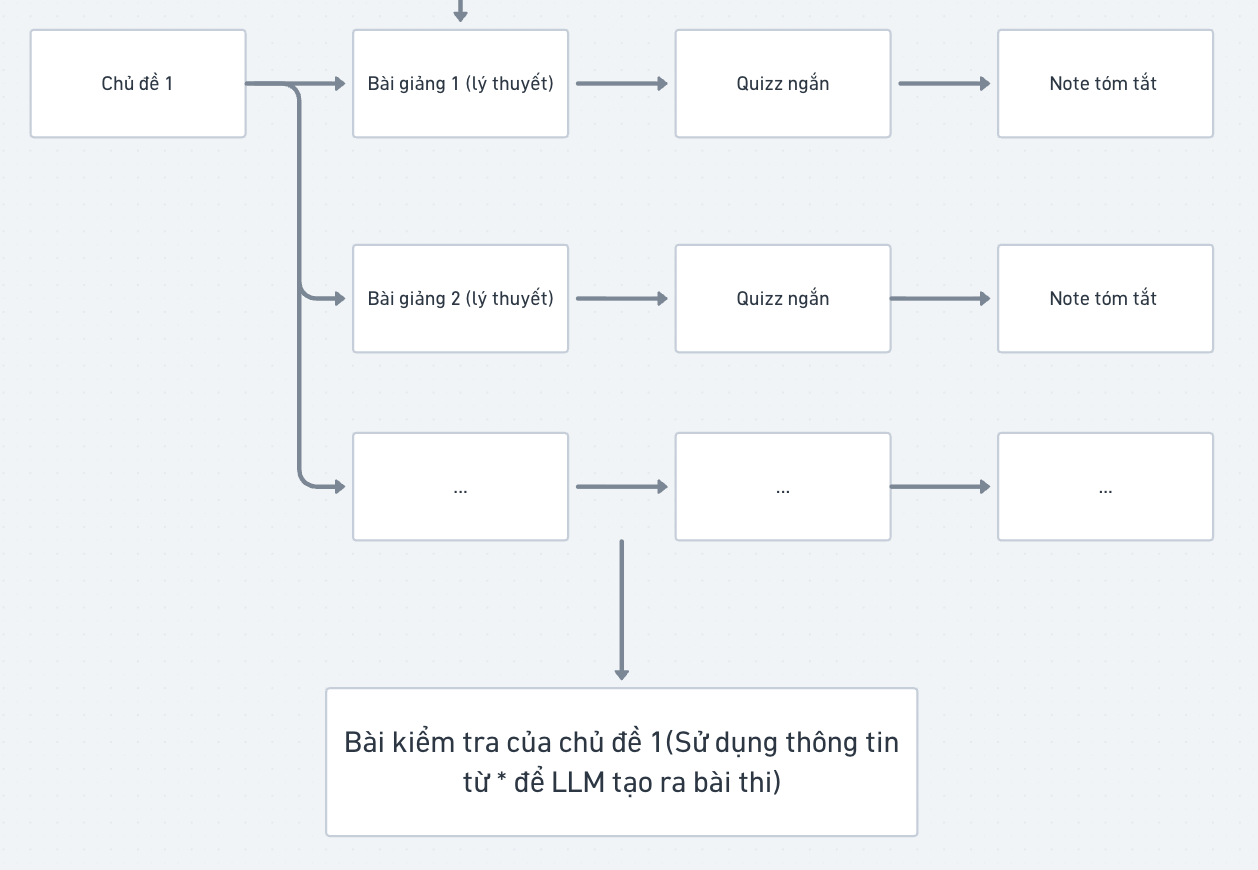

In [1]:
from typing import TypedDict, List, Optional, Dict
from pydantic import BaseModel, Field
# from langchain_openai import OpenAI
from openai import OpenAI

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage
import instructor

import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class QuizzOptions(BaseModel):
    text: str = Field(..., description="Nội dung đáp án")
    is_true: bool = Field(..., description="Đáp án đúng hay sai")

class Quizz(BaseModel):
    question: str = Field(..., description="Câu hỏi trắc nghiệm")
    options: List[QuizzOptions] = Field(..., description="Danh sách các đáp án")

class Lession(BaseModel):
    title: str | None = Field(None, description="Tiêu đề bài giảng con")
    theory: str | None = Field(None, description="Nội dung lý thuyết / bài giảng")
    quizzes: List[Quizz] | None = Field(None, description="Danh sách câu hỏi trắc nghiệm")
    summary_note: str | None = Field(None, description="Ghi chú tóm tắt cuối bài")
class AgentState(BaseModel):
    lessions: List[Lession] = Field(..., description="Danh sách các bài giảng con")
    final_quizz: List[Quizz] = Field(..., description="Các câu hỏi cuối cùng để kiểm tra xem người dùng có đủ khả năng qua bài chủ đề khác không")

In [3]:
def multiple_lession_spliting(topic: Dict):
    SYSTEM_PROMPT = f"""
    Bạn là một chuyên gia về giáo dục. Tôi sẽ cung cấp một chủ đề như sau:
    TÊN TOPIC: {topic['topic']}
    TÓM TẮT:  {topic['summary']}
    LỜI NÓI CỦA GIẢNG VIÊN: {topic['sub_text']}
    Chủ đề đó được tách ra từ một video lớn hơn của giảng viên đó.
    Việc của bạn là tách ra thành các bài giảng con theo định dạng như sau, không được quá 5 bài giảng
    {json.dumps(AgentState.model_json_schema(), ensure_ascii=False, indent=2)}

    ### Lưu ý:
    - final_quizz phải có đủ số câu hỏi, thể hiện được phân hóa học sinh, 
    các câu hỏi phải đúng để nhận biết được học sinh đã hiểu được bài hay chưa để có thể học sang bài khác
    - Mỗi bài đều cần summary_note là mỏ neo tri thức, không được để trống
    """


    client = instructor.from_openai(
        OpenAI(
            base_url="https://openrouter.ai/api/v1",
            api_key=os.getenv("OPENROUTER_API_KEY"),
        )
    )

    print("Dang phan tach chu de voi LLM...")
    lessions = client.chat.completions.create(
        model="deepseek/deepseek-v4.1-flash",
        response_model=AgentState,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Transcribe cua bai giang:\n\n{topic['sub_text']}"},
        ],
        temperature=0.2,
    )

    return lessions


def _render_quizz(quizzes, heading):
    """Render HTML for a list of quizzes."""
    from IPython.display import display, HTML

    quiz_items = ""
    for j, q in enumerate(quizzes or [], 1):
        opts = "".join(
            f"<li>{'✅' if o.is_true else '❌'} {o.text}</li>"
            for o in q.options
        )
        quiz_items += f"<p><b>Câu {j}.</b> {q.question}</p><ul style='list-style:none;padding-left:0;'>{opts}</ul>"

    html = f"""
    <div style="max-width:700px;font-family:sans-serif;line-height:1.6;margin-bottom:24px;">
      <h4 style="color:#374151;">{heading}</h4>
      {quiz_items}
    </div>
    """
    display(HTML(html))


def display_lessons(res):
    from IPython.display import display, HTML

    for i, l in enumerate(res.lessions, 1):
        quiz_items = ""
        for j, q in enumerate(l.quizzes or [], 1):
            opts = "".join(
                f"<li>{'✅' if o.is_true else '❌'} {o.text}</li>"
                for o in q.options
            )
            quiz_items += f"<p><b>Câu {j}.</b> {q.question}</p><ul style='list-style:none;padding-left:0;'>{opts}</ul>"

        note_html = f"<blockquote style='border-left:3px solid #f59e0b;padding-left:12px;color:#92400e;'>💡 <b>Ghi chú:</b> {l.summary_note}</blockquote>" if l.summary_note else ""

        html = f"""
        <div style="max-width:700px;font-family:sans-serif;line-height:1.6;margin-bottom:24px;">
          <h2 style="color:#1e40af;">Bài {i}: {l.title}</h2>
          <h4 style="color:#374151;">Lý thuyết</h4>
          <div style="background:#f9fafb;padding:12px;border-radius:6px;">{l.theory}</div>
          <h4 style="color:#374151;margin-top:16px;">Câu hỏi trắc nghiệm</h4>
          {quiz_items}
          {note_html}
        </div>
        """
        display(HTML(html))

    # Final quizz - bai kiem tra cuoi chu de
    if hasattr(res, 'final_quizz') and res.final_quizz:
        quiz_items = ""
        for j, q in enumerate(res.final_quizz, 1):
            opts = "".join(
                f"<li>{'✅' if o.is_true else '❌'} {o.text}</li>"
                for o in q.options
            )
            quiz_items += f"<p><b>Câu {j}.</b> {q.question}</p><ul style='list-style:none;padding-left:0;'>{opts}</ul>"

        html = f"""
        <div style="max-width:700px;font-family:sans-serif;line-height:1.6;margin-bottom:24px;border:2px solid #dc2626;border-radius:8px;padding:16px;">
          <h2 style="color:#dc2626;">📝 Kiểm tra cuối chủ đề</h2>
          <p style="color:#6b7280;font-style:italic;">Hoàn thành bài kiểm tra này để chuyển sang chủ đề khác</p>
          {quiz_items}
        </div>
        """
        display(HTML(html))

In [4]:
import json

with open("../data/json/RECORD_CongThucLuongGiac_res.json", "r", encoding="utf-8") as f:
    topics = json.load(f)

In [5]:
index = 1
print("Topic:", topics['topics'][index]['topic'])
print("Tóm tắt:", topics['topics'][index]['summary'])

res = multiple_lession_spliting(topic=topics['topics'][index])

Topic: Hệ thức lượng trong tam giác
Tóm tắt: Ôn tập hệ thức lượng trong tam giác vuông, mở rộng sang tam giác bất kỳ với định lý côsin và định lý sin. Phân tích chứng minh định lý côsin dựa trên vectơ và ứng dụng tính cạnh, góc trong tam giác.
Dang phan tach chu de voi LLM...


In [6]:
print(res.model_dump_json(indent=True, ensure_ascii=False))

{
 "lessions": [
  {
   "title": "Ôn tập hệ thức lượng trong tam giác vuông",
   "theory": "## 1. Nhắc lại tam giác vuông\n\nXét tam giác ABC vuông tại A. Kẻ đường cao AH vuông góc với cạnh huyền BC. Ta đặt tên các đoạn thẳng như sau:\n\n- Cạnh huyền: BC = a\n- Cạnh góc vuông: AC = b, AB = c\n- Đường cao: AH = h\n- Hình chiếu: BH = c' (hình chiếu của AB lên BC), CH = b' (hình chiếu của AC lên BC)\n\n## 2. Các hệ thức lượng cần nhớ\n\nToàn bộ các công thức dưới đây đã được chứng minh ở cấp 2 dựa vào các cặp tam giác đồng dạng, nên khi làm bài các em **được phép sử dụng trực tiếp, không cần chứng minh lại**:\n\n**Nhóm 1 – Hệ thức về cạnh góc vuông và hình chiếu:**\n- b² = b'·a\n- c² = c'·a\n\n**Nhóm 2 – Định lý Pythagoras:**\n- a² = b² + c²\n\n**Nhóm 3 – Hệ thức về đường cao:**\n- a·h = b·c\n- h² = b'·c'\n- 1/h² = 1/b² + 1/c²\n\n## 3. Ý nghĩa\n\nCác hệ thức này cho phép ta chuyển đổi qua lại giữa cạnh, đường cao và hình chiếu khi biết một số yếu tố. Đây là \"bàn đạp\" để mở rộng sang tam

In [7]:
display_lessons(res)